In [33]:
#!pip install torch-geometric

In [34]:
#!pip install PyTDC

In [35]:
import warnings, random, os, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from tqdm.notebook import tqdm
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR  # CosineAnnealingLR gradually decreases the learning rate following a cosine curve.
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, GCNConv, global_mean_pool
from rdkit import Chem
from rdkit.Chem import BRICS, Descriptors, Draw, AllChem
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
from rdkit.Chem import rdMolDescriptors
from IPython.display import display, Image
import pickle

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, accuracy_score,
    confusion_matrix, classification_report
)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

try:
    from tdc.multi_pred import DDI
    TDC_AVAILABLE = True
    print('[OK] TDC available - will use DrugBank data')
except ImportError:
    TDC_AVAILABLE = False
    print("[WARN TDC not installed")

[OK] TDC available - will use DrugBank data


In [36]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ATOM_FEATURE_DIM = 79
BOND_FEATURE_DIM = 10
FP_DIM = 512

In [37]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11
})
PALETTE = ['#4361ee', '#f72585', '#3a86ff', '#06d6a0', '#ffd166', '#ef476f']

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128


# Section 2: Data Loading

We will use DrugBank dataset accessed via the Therapeutic Data Commons (TDC) with a **cold-drug split** — 20% of drugs are fully withheld from training to simulate real world prediction on new drug candidates.

In [38]:
def load_drugbank(cold_split=True):
    if TDC_AVAILABLE:
        print('Downloading DrugBank from TDC (first run ~1 min)...')
        data  = DDI(name='DrugBank')

        # Data Statistics
        df_full = data.get_data()
        orig_pairs = len(df_full)
        orig_unique_drugs = pd.concat([df_full['Drug1_ID'], df_full['Drug2_ID']]).nunique()
        print(f"--- Original Data Statistics ---")
        print(f"  Total Pairs: {orig_pairs:,}")
        print(f"  Unique Drugs: {orig_unique_drugs:,}")
        display(df_full.head())

        # Splitting
        if cold_split:
            split = data.get_split(method='cold_split', 
                                   column_name=['Drug1_ID', 'Drug2_ID'], 
                                   seed=SEED)
        else:
            split = data.get_split(method='random', seed=SEED)
            
        tr, vl, te = split['train'], split['valid'], split['test']
        for df in [tr, vl, te]:
            df.rename(columns={'Y': 'label'}, inplace=True)
        smiles_map = {}
        for df in [tr, vl, te]:
            for _, r in df.iterrows():
                smiles_map[r['Drug1_ID']] = r['Drug1']
                smiles_map[r['Drug2_ID']] = r['Drug2']
        le = LabelEncoder()
        all_l = pd.concat([tr['label'], vl['label'], te['label']])
        le.fit(all_l)
        for df in [tr, vl, te]:
            df['label'] = le.transform(df['label'])
        return tr, vl, te, smiles_map, len(le.classes_), le
    else:
        return _synthetic_fallback()

In [39]:
def _synthetic_fallback(n=3000, n_classes=10):
    """SMILES for demo if TDC unavailable."""
    smis = [
        'CC(=O)Oc1ccccc1C(=O)O', 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
        'CC(C)Cc1ccc(cc1)C(C)C(=O)O', 'CC(=O)Nc1ccc(O)cc1',
        'O=C(O)c1ccccc1O', 'c1ccc2c(c1)CC(=O)N2',
        'CCOC(=O)c1cnc2cc(OC)c(OC)cc2c1C(=O)OCC',
        'OC[C@H]1O[C@@H](n2cnc3c(N)ncnc23)[C@H](O)[C@@H]1O',
        'Clc1ccc(cc1)C(c2ccccc2)N3CCNCC3',
        'CC(O)(P(=O)(O)O)P(=O)(O)O',
        'CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C',
        'c1ccc(cc1)CN2CCNCC2',
        'Fc1ccc(cc1)C(=O)CCCN2CCC(CC2)c3noc4cc(F)ccc34',
        'O=C1CN=C(c2ccccc2)c2cc(Cl)ccc21',
        'CC(=O)c1ccc(cc1)N', 'CNCCC(Oc1ccc(CC)cc1)c1ccccc1'
    ]
    drug_names = [
        'Aspirin', 'Caffeine', 'Ibuprofen', 'Paracetamol',
        'Salicylate', 'Oxindole', 'Amlodipine-like', 'Adenosine',
        'Meclizine-like', 'Etidronate', 'Testosterone', 'Phenylpiperazine',
        'Droperidol-like', 'Diazepam-like', 'Acetaminophen', 'Fluoxetine-like'
    ]
    ids = [f'DB{i:05d}' for i in range(len(smis))]
    smiles_map = dict(zip(ids, smis))
    name_map   = dict(zip(ids, drug_names))
    interaction_types = [
        'increases toxicity', 'decreases efficacy', 'increases serum level',
        'decreases serum level', 'risk of bleeding', 'CNS depression',
        'serotonin syndrome', 'QT prolongation', 'hypotension', 'hyperkalemia'
    ]
    rows = []
    for _ in range(n):
        d1, d2 = random.sample(ids, 2)
        rows.append({'Drug1_ID': d1, 'Drug2_ID': d2,
                     'Drug1': smiles_map[d1], 'Drug2': smiles_map[d2],
                     'label': random.randint(0, n_classes-1)})
    df = pd.DataFrame(rows)
    tr, tmp = train_test_split(df, test_size=0.3, random_state=SEED)
    vl, te  = train_test_split(tmp, test_size=0.5, random_state=SEED)
    le = type('LE', (), {'classes_': interaction_types})()  # mock le
    return tr, vl, te, smiles_map, n_classes, le

In [40]:
print('Loading data...')
train_df, val_df, test_df, smiles_map, n_classes, label_encoder = load_drugbank(cold_split=True)
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"\n--- Split Data Statistics ---")
print(f'  Interaction types: {n_classes}')
print(f'  Train pairs: {len(train_df):,}')
print(f'  Val pairs: {len(val_df):,}')
print(f'  Test pairs: {len(test_df):,}')
print(f'  Unique drugs: {len(smiles_map):,}')
print(f'  Total pairs: {len(all_df):,}')

Found local copy...
Loading...


Loading data...


Done!


--- Original Data Statistics ---
  Total Pairs: 191,808
  Unique Drugs: 1,706


,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,DB04571,CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
1,DB00855,NCC(=O)CCC(O)=O,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
2,DB09536,O=[Ti]=O,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
3,DB01600,CC(C(O)=O)C1=CC=C(S1)C(=O)C1=CC=CC=C1,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
4,DB09000,CC(CN(C)C)CN1C2=CC=CC=C2SC2=C1C=C(C=C2)C#N,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1



--- Split Data Statistics ---
  Interaction types: 86
  Train pairs: 94,892
  Val pairs: 1,835
  Test pairs: 7,527
  Unique drugs: 1,646
  Total pairs: 104,254


In [41]:
print("--- Records per Interaction Type (Training Set) ---")
print(train_df['label'].value_counts())

--- Records per Interaction Type (Training Set) ---
label
48    29993
46    17186
72    12101
74     4544
59     4193
      ...  
42        6
41        6
25        4
51        2
14        1
Name: count, Length: 81, dtype: int64


# Section 3 : EDA

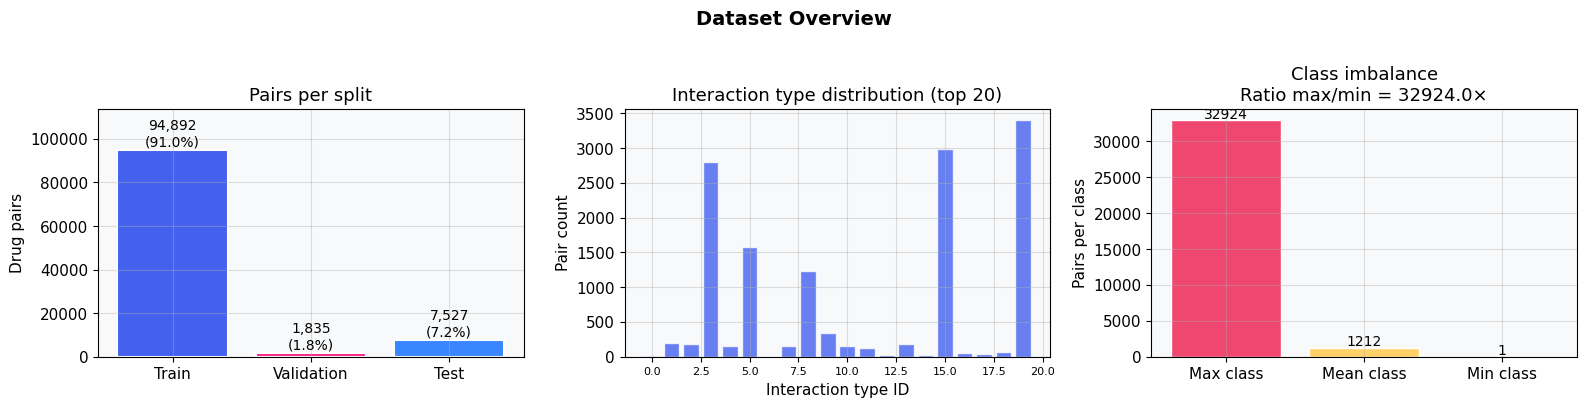

Imbalance ratio (max/min) : 32924.0×  ← justifies Focal Loss


In [42]:
split_sizes = {'Train': len(train_df), 'Validation': len(val_df), 'Test': len(test_df)}
total = sum(split_sizes.values())
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.01)

# Split sizes
ax = axes[0]
bars = ax.bar(split_sizes.keys(), split_sizes.values(),
              color=PALETTE[:3], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, split_sizes.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+total*0.005,
            f'{v:,}\n({v/total*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Pairs per split'); ax.set_ylabel('Drug pairs')
ax.set_ylim(0, max(split_sizes.values())*1.2)

# Class distribution (top 20 if many classes)
ax = axes[1]
label_counts = all_df['label'].value_counts().sort_index()
top_n = min(20, len(label_counts))
top_labels = label_counts.head(top_n)
ax.bar(range(len(top_labels)), top_labels.values,
       color='#4361ee', alpha=0.8, edgecolor='white')
ax.set_title(f'Interaction type distribution (top {top_n})')
ax.set_xlabel('Interaction type ID'); ax.set_ylabel('Pair count')
ax.tick_params(axis='x', labelsize=8)

# Imbalance ratio
ax = axes[2]
max_c = label_counts.max(); min_c = label_counts.min(); mean_c = label_counts.mean()
ax.bar(['Max class', 'Mean class', 'Min class'], [max_c, mean_c, min_c],
       color=['#ef476f', '#ffd166', '#06d6a0'], edgecolor='white')
ax.set_title(f'Class imbalance\nRatio max/min = {max_c/max(min_c,1):.1f}×')
ax.set_ylabel('Pairs per class')
for i, v in enumerate([max_c, mean_c, min_c]):
    ax.text(i, v+max_c*0.01, f'{v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_split_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio (max/min) : {max_c/max(min_c,1):.1f}×  ← justifies Focal Loss')

Building interaction graph


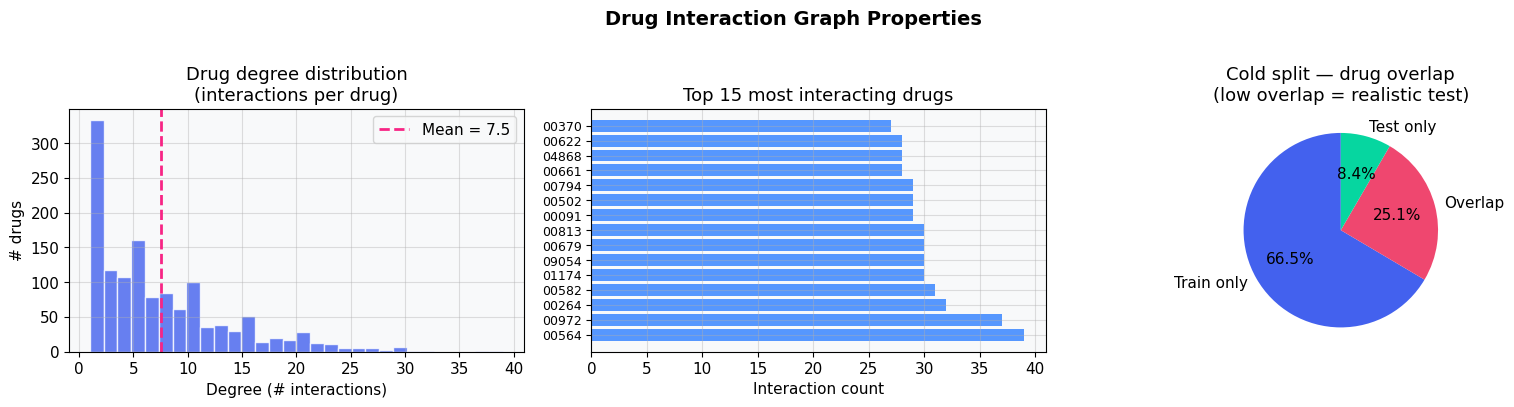

Graph nodes (drugs): 1,331
Graph edges (pairs): 4,999
Mean degree: 7.5
Max degree: 39
Train/test overlap: 407 drugs (75.0% of test)


In [43]:
print('Building interaction graph')
G = nx.Graph()

# Subsample for visualisation if too large
sample_df = all_df.sample(min(5000, len(all_df)), random_state=SEED)
for _, row in sample_df.iterrows():
    G.add_edge(row['Drug1_ID'], row['Drug2_ID'], label=row['label'])

degrees = [d for _, d in G.degree()]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Drug Interaction Graph Properties', fontsize=14, fontweight='bold', y=1.01)

# Degree distribution
ax = axes[0]
ax.hist(degrees, bins=30, color='#4361ee', alpha=0.8, edgecolor='white')
ax.set_title('Drug degree distribution\n(interactions per drug)')
ax.set_xlabel('Degree (# interactions)'); ax.set_ylabel('# drugs')
ax.axvline(np.mean(degrees), color='#f72585', linestyle='--', lw=2,
           label=f'Mean = {np.mean(degrees):.1f}')
ax.legend()

# Top 15 most connected drugs
ax = axes[1]
top_drugs = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:15]
d_ids, d_degs = zip(*top_drugs)
short_ids = [i[-5:] for i in d_ids]  # show last 5 chars of ID
ax.barh(range(len(d_degs)), d_degs, color='#3a86ff', alpha=0.85)
ax.set_yticks(range(len(d_degs))); ax.set_yticklabels(short_ids, fontsize=9)
ax.set_title('Top 15 most interacting drugs'); ax.set_xlabel('Interaction count')

# Train/val/test drug overlap (cold split verification)
ax = axes[2]
train_drugs = set(train_df['Drug1_ID'].tolist() + train_df['Drug2_ID'].tolist())
test_drugs  = set(test_df['Drug1_ID'].tolist()  + test_df['Drug2_ID'].tolist())
overlap     = train_drugs & test_drugs
train_only  = train_drugs - test_drugs
test_only   = test_drugs  - train_drugs

wedges, texts, autotexts = ax.pie(
    [len(train_only), len(overlap), len(test_only)],
    labels=['Train only', 'Overlap', 'Test only'],
    colors=['#4361ee', '#ef476f', '#06d6a0'],
    autopct='%1.1f%%', startangle=90
)
ax.set_title('Cold split — drug overlap\n(low overlap = realistic test)')

plt.tight_layout()
plt.savefig('eda_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Graph nodes (drugs): {G.number_of_nodes():,}')
print(f'Graph edges (pairs): {G.number_of_edges():,}')
print(f'Mean degree: {np.mean(degrees):.1f}')
print(f'Max degree: {max(degrees)}')
print(f'Train/test overlap: {len(overlap)} drugs ({len(overlap)/len(test_drugs)*100:.1f}% of test)')

# Section 4: Molecular feature analysis

In [44]:
print('computing molecular descriptors')

def compute_descriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return {
        'mol_weight': Descriptors.MolWt(mol),
        'logp': Descriptors.MolLogP(mol),
        'hbd': rdMolDescriptors.CalcNumHBD(mol),   # H-bond donors
        'hba': rdMolDescriptors.CalcNumHBA(mol),   # H-bond acceptors
        'tpsa': rdMolDescriptors.CalcTPSA(mol),     # topological polar surface
        'rotatable': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'aromatic_rings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'n_atoms': mol.GetNumAtoms(),
        'n_bonds': mol.GetNumBonds(),
        'n_rings': rdMolDescriptors.CalcNumRings(mol),
        'n_stereocenters': len(Chem.FindMolChiralCenters(mol, includeUnassigned=True)),
        'smiles': smi,
    }

desc_rows =[]
for did, smi in tqdm(smiles_map.items(), desc="Descriptors"):
    d = compute_descriptors(smi)
    if d:
        d["drug_id"] = did
        desc_rows.append(d)

desc_df = pd.DataFrame(desc_rows)
print(f'\nDescriptors computed for {len(desc_df):,} drugs')
desc_df.describe().round(2)

computing molecular descriptors


Descriptors:   0%|          | 0/1646 [00:00<?, ?it/s]

[08:49:27] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[08:49:27] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'



Descriptors computed for 1,645 drugs


,mol_weight,logp,hbd,hba,tpsa,rotatable,aromatic_rings,n_atoms,n_bonds,n_rings,n_stereocenters
count,1645.00,1645.00,1645.00,1645.00,1645.00,1645.00,1645.00,1645.00,1645.00,1645.00,1645.00
mean,394.57,2.13,2.30,5.54,97.03,5.79,1.57,27.19,28.96,2.94,2.49
std,325.95,3.29,4.01,6.57,131.26,8.64,1.40,22.15,23.66,2.26,4.69
min,6.94,-27.13,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
25%,260.31,0.94,1.00,3.00,43.86,2.00,1.00,18.00,19.00,2.00,0.00
50%,337.46,2.55,2.00,4.00,72.83,4.00,1.00,24.00,26.00,3.00,1.00
75%,435.89,3.91,3.00,6.00,108.74,7.00,2.00,30.00,33.00,4.00,3.00
max,7177.25,17.85,81.00,180.00,2404.82,176.00,26.00,457.00,502.00,46.00,89.00


In [45]:
desc_df

,mol_weight,logp,hbd,hba,tpsa,rotatable,aromatic_rings,n_atoms,n_bonds,n_rings,n_stereocenters,smiles,drug_id
0,228.247,3.46446,0,3,43.35,0,3,17,19,3,0,CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1,DB04571
1,718.807,6.71924,3,9,173.56,9,3,53,58,6,2,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,DB00460
2,131.131,-0.62100,2,3,80.39,4,0,9,8,0,0,NCC(=O)CCC(O)=O,DB00855
3,79.865,-0.24010,0,2,34.14,0,0,3,2,0,0,O=[Ti]=O,DB09536
4,260.314,3.16720,1,3,54.37,4,2,18,19,2,1,CC(C(O)=O)C1=CC=C(S1)C(=O)C1=CC=CC=C1,DB01600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640,24.305,-0.38080,0,0,0.00,0,0,1,0,0,0,[Mg++],DB01378
1641,395.422,-0.17180,4,9,158.21,5,1,26,28,3,2,[H][C@]12SCC(C=C)=C(N1C(=O)[C@H]2NC(=O)C(=N/O)...,DB00535
1642,78.960,-0.38080,0,0,0.00,0,0,1,0,0,0,[Se],DB11135
1643,147.130,-0.73690,3,3,100.62,4,0,10,9,0,1,N[C@@H](CCC(O)=O)C(O)=O,DB00142


In [46]:
desc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1645 entries, 0 to 1644
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mol_weight       1645 non-null   float64
 1   logp             1645 non-null   float64
 2   hbd              1645 non-null   int64  
 3   hba              1645 non-null   int64  
 4   tpsa             1645 non-null   float64
 5   rotatable        1645 non-null   int64  
 6   aromatic_rings   1645 non-null   int64  
 7   n_atoms          1645 non-null   int64  
 8   n_bonds          1645 non-null   int64  
 9   n_rings          1645 non-null   int64  
 10  n_stereocenters  1645 non-null   int64  
 11  smiles           1645 non-null   object 
 12  drug_id          1645 non-null   object 
dtypes: float64(3), int64(8), object(2)
memory usage: 167.2+ KB


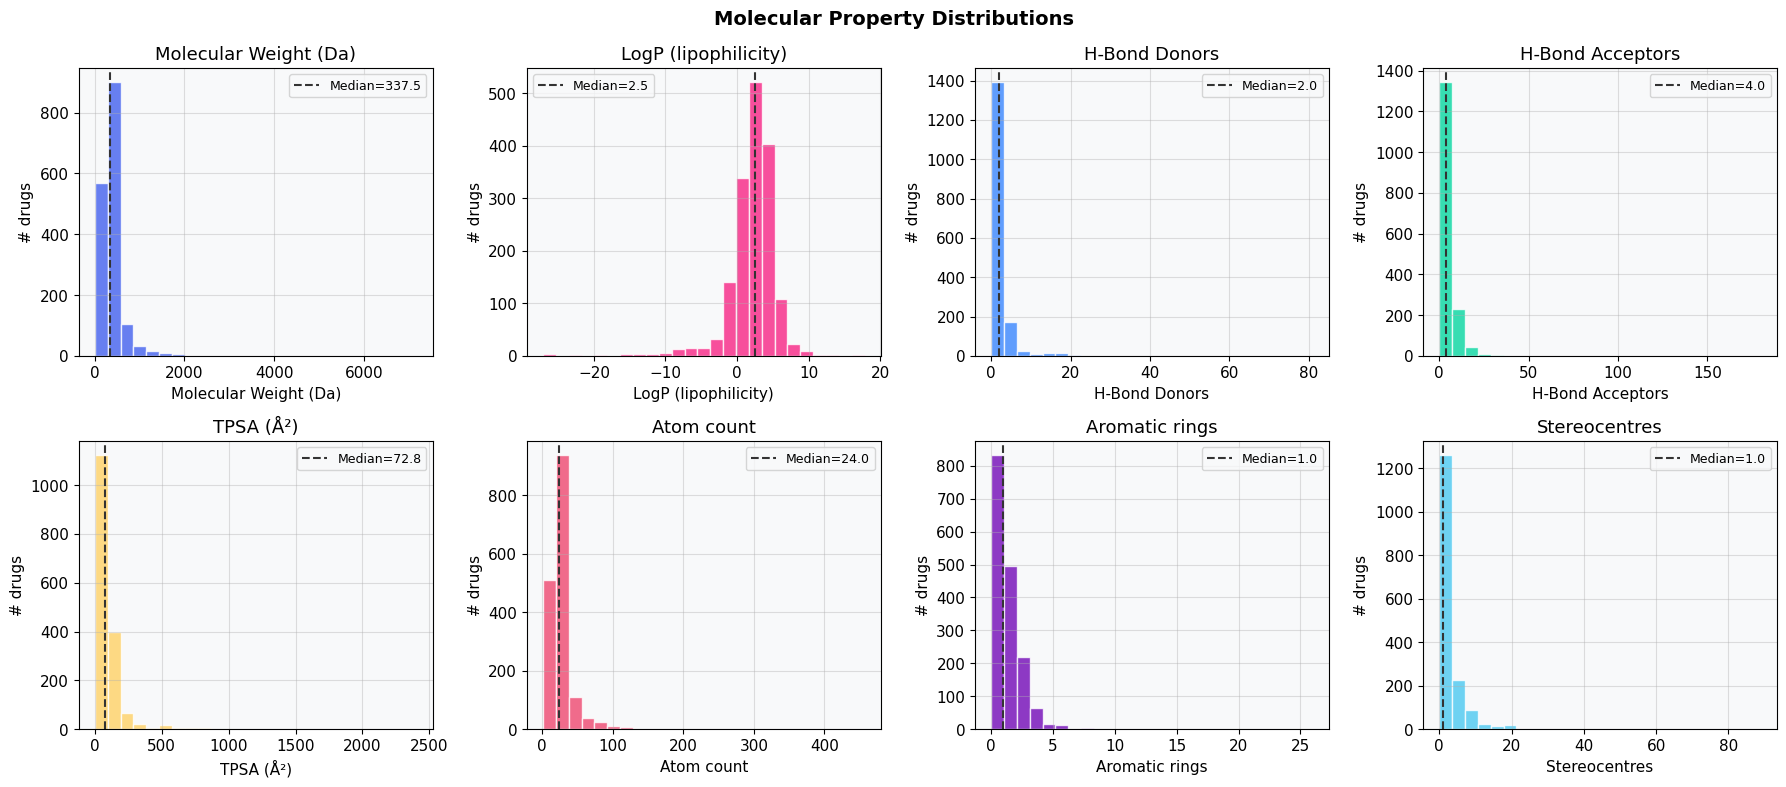

Lipinski Rule-of-5 compliant drugs: 1,247 / 1,645 (75.8%)


In [47]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Molecular Property Distributions', fontsize=14, fontweight='bold')

props = [
    ('mol_weight','Molecular Weight (Da)','#4361ee'),
    ('logp','LogP (lipophilicity)','#f72585'),
    ('hbd','H-Bond Donors','#3a86ff'),
    ('hba','H-Bond Acceptors','#06d6a0'),
    ('tpsa','TPSA (Å²)','#ffd166'),
    ('n_atoms','Atom count','#ef476f'),
    ('aromatic_rings','Aromatic rings','#7209b7'),
    ('n_stereocenters','Stereocentres','#4cc9f0'),
]

for ax, (col, label, color) in zip(axes.flat, props):
    data = desc_df[col].dropna()
    ax.hist(data, bins=25, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel(label); ax.set_ylabel('# drugs')
    ax.axvline(data.median(), color='#333', linestyle='--', lw=1.5,
               label=f'Median={data.median():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_mol_props.png', dpi=150, bbox_inches='tight')
plt.show()

# Lipinski's Rule of 5 compliance
ro5 = desc_df[
    (desc_df['mol_weight']<=500) &
    (desc_df['logp']<=5) &
    (desc_df['hbd']<=5) &
    (desc_df['hba']<=10)
]
print(f"Lipinski Rule-of-5 compliant drugs: {len(ro5):,} / {len(desc_df):,} ({len(ro5)/len(desc_df)*100:.1f}%)")

*75.8% compliance. This is very high! It means the DrugBank dataset is mostly made of "real" medicines designed for humans, rather than random industrial chemicals.*

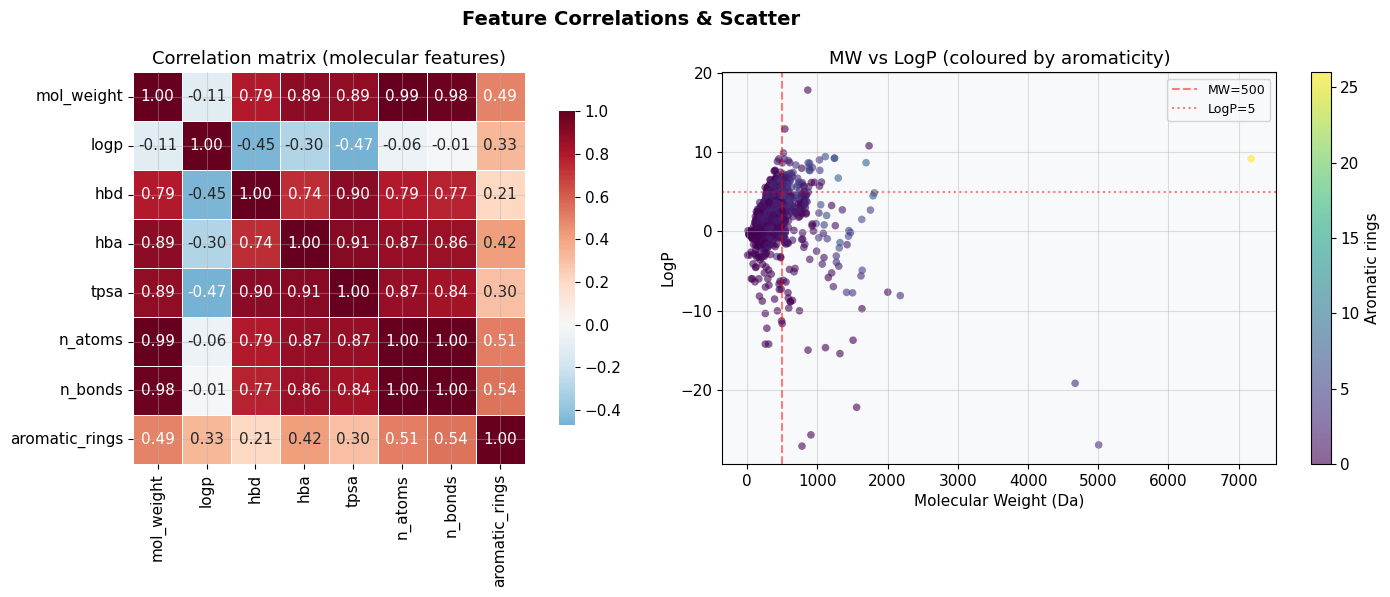

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Correlations & Scatter', fontsize=14, fontweight='bold')

corr_cols = ['mol_weight','logp','hbd','hba','tpsa','n_atoms','n_bonds','aromatic_rings']
corr = desc_df[corr_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], cbar_kws={'shrink': 0.8},
            linewidths=0.5, square=True)
axes[0].set_title('Correlation matrix (molecular features)')

# MW vs LogP scatter coloured by aromatic rings
sc = axes[1].scatter(desc_df['mol_weight'], desc_df['logp'],
                     c=desc_df['aromatic_rings'], cmap='viridis',
                     alpha=0.6, s=30, edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='Aromatic rings')
axes[1].set_xlabel('Molecular Weight (Da)')
axes[1].set_ylabel('LogP')
axes[1].set_title('MW vs LogP (coloured by aromaticity)')
# Lipinski boundaries
axes[1].axvline(500, color='red', linestyle='--', alpha=0.5, label='MW=500')
axes[1].axhline(5,   color='red', linestyle=':',  alpha=0.5, label='LogP=5')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_corr.png', dpi=150, bbox_inches='tight')
plt.show()

Parsing molecular graphs for structure statistics


Parsing graphs:   0%|          | 0/500 [00:00<?, ?it/s]

[08:49:32] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[08:49:32] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'


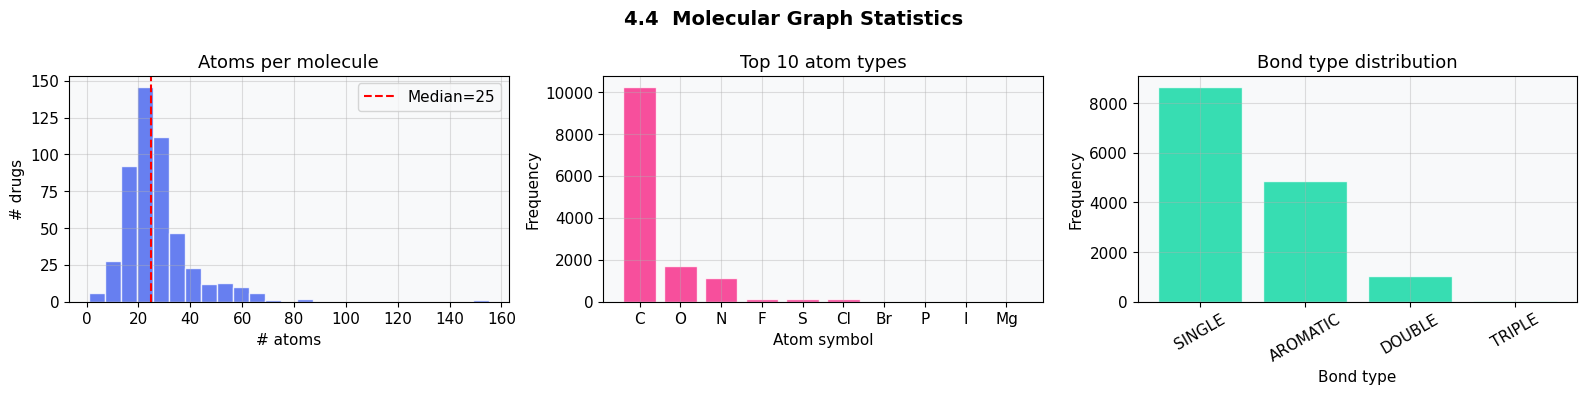

Mean atoms/mol : 27.1  |  Std: 13.3
Mean bonds/mol : 29.2  |  Std: 14.4
Most common atom: C (10,261 occurrences)


In [49]:
print('Parsing molecular graphs for structure statistics')

atom_counts, bond_counts, ring_counts = [], [], []
atom_type_counter = Counter()
bond_type_counter = Counter()

sample_smiles = list(smiles_map.values())[:min(500, len(smiles_map))]
for smi in tqdm(sample_smiles, desc='Parsing graphs'):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: continue
    atom_counts.append(mol.GetNumAtoms())
    bond_counts.append(mol.GetNumBonds())
    ring_counts.append(rdMolDescriptors.CalcNumRings(mol))
    for atom in mol.GetAtoms():
        atom_type_counter[atom.GetSymbol()] += 1
    for bond in mol.GetBonds():
        bond_type_counter[str(bond.GetBondType()).split('.')[-1]] += 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('4.4  Molecular Graph Statistics', fontsize=14, fontweight='bold')

axes[0].hist(atom_counts, bins=25, color='#4361ee', alpha=0.8, edgecolor='white')
axes[0].set_title('Atoms per molecule')
axes[0].set_xlabel('# atoms'); axes[0].set_ylabel('# drugs')
axes[0].axvline(np.median(atom_counts), color='red', linestyle='--',
                label=f'Median={np.median(atom_counts):.0f}')
axes[0].legend()

top_atoms = atom_type_counter.most_common(10)
a_syms, a_cnts = zip(*top_atoms)
axes[1].bar(a_syms, a_cnts, color='#f72585', alpha=0.8, edgecolor='white')
axes[1].set_title('Top 10 atom types')
axes[1].set_xlabel('Atom symbol'); axes[1].set_ylabel('Frequency')

top_bonds = bond_type_counter.most_common(6)
b_types, b_cnts = zip(*top_bonds)
axes[2].bar(b_types, b_cnts, color='#06d6a0', alpha=0.8, edgecolor='white')
axes[2].set_title('Bond type distribution')
axes[2].set_xlabel('Bond type'); axes[2].set_ylabel('Frequency')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_graph_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean atoms/mol : {np.mean(atom_counts):.1f}  |  Std: {np.std(atom_counts):.1f}')
print(f'Mean bonds/mol : {np.mean(bond_counts):.1f}  |  Std: {np.std(bond_counts):.1f}')
print(f'Most common atom: {top_atoms[0][0]} ({top_atoms[0][1]:,} occurrences)')

Rendering sample drug structures


[08:49:33] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[08:49:33] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'


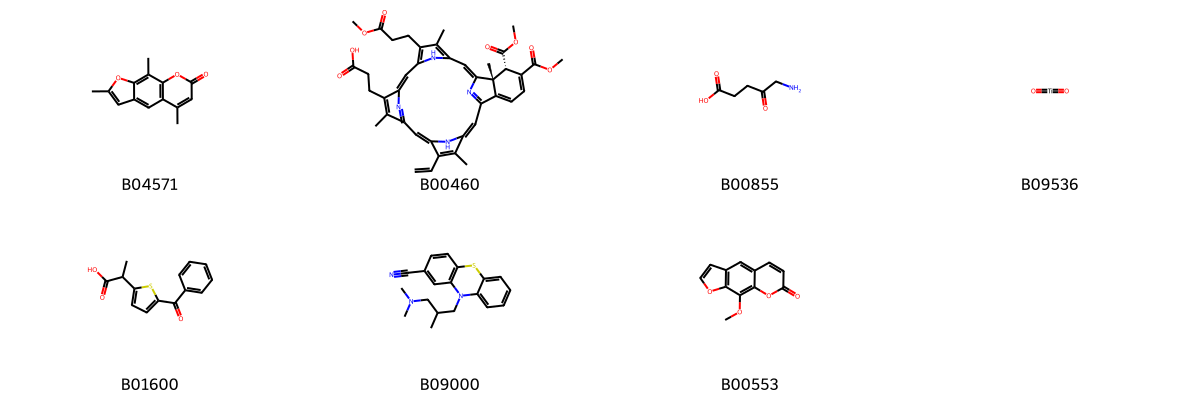

Sample drug structures rendered above.


In [50]:
print('Rendering sample drug structures')
sample_ids = list(smiles_map.keys())[:8]
mols, legends = [], []
for did in sample_ids:
    smi = smiles_map[did]
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mols.append(mol)
        legends.append(did[-6:])  # short ID

if mols:
    img = Draw.MolsToGridImage(
        mols[:8], molsPerRow=4, subImgSize=(300, 200),
        legends=legends[:8]
    )
    display(img)
    print('Sample drug structures rendered above.')

Analysing BRICS fragment distribution


BRICS:   0%|          | 0/500 [00:00<?, ?it/s]

[08:49:34] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[08:49:34] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'


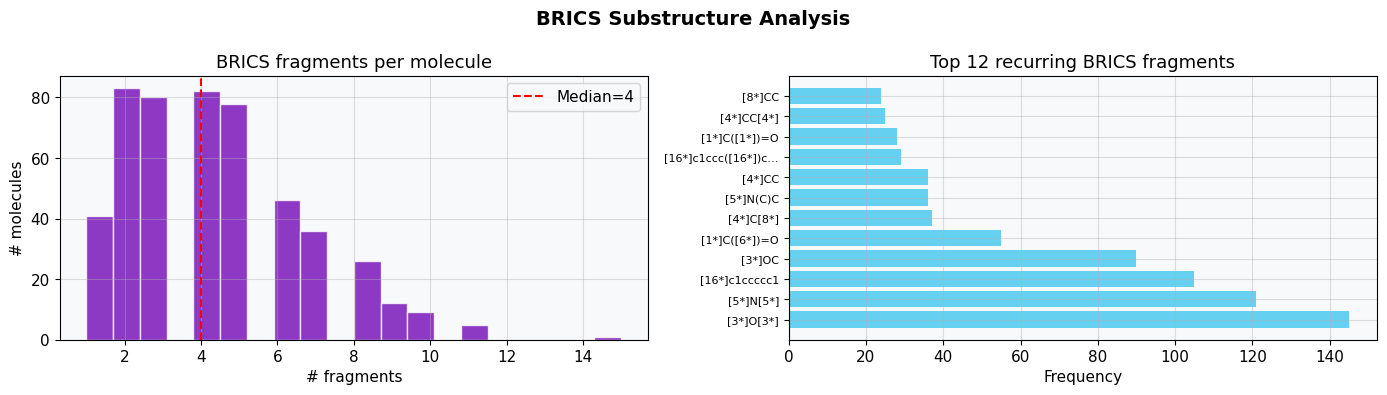

Unique BRICS fragments found : 786
Mean fragments per molecule  : 4.3


In [51]:
print('Analysing BRICS fragment distribution')

frag_counts = []
all_frags   = Counter()

for smi in tqdm(sample_smiles, desc='BRICS'):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: continue
    frags = list(BRICS.BRICSDecompose(mol))
    frag_counts.append(len(frags))
    for f in frags:
        all_frags[f] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('BRICS Substructure Analysis', fontsize=14, fontweight='bold')

axes[0].hist(frag_counts, bins=20, color='#7209b7', alpha=0.8, edgecolor='white')
axes[0].set_title('BRICS fragments per molecule')
axes[0].set_xlabel('# fragments'); axes[0].set_ylabel('# molecules')
axes[0].axvline(np.median(frag_counts), color='red', linestyle='--',
                label=f'Median={np.median(frag_counts):.0f}')
axes[0].legend()

top_frags = all_frags.most_common(12)
# Shorten fragment SMILES for display
f_labels = [f[0][:18]+'…' if len(f[0])>18 else f[0] for f in top_frags]
f_cnts   = [f[1] for f in top_frags]
axes[1].barh(range(len(f_labels)), f_cnts, color='#4cc9f0', alpha=0.85)
axes[1].set_yticks(range(len(f_labels)))
axes[1].set_yticklabels(f_labels, fontsize=8)
axes[1].set_title('Top 12 recurring BRICS fragments')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('eda_brics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Unique BRICS fragments found : {len(all_frags):,}')
print(f'Mean fragments per molecule  : {np.mean(frag_counts):.1f}')

# Section 5: Feature Engineering & Featurisation

In [52]:
def atom_features(atom):
    def oh(val, choices):
        v = [0]*len(choices)
        if val in choices: v[choices.index(val)] = 1
        else: v[-1] = 1
        return v
    atomic_nums   = [1,5,6,7,8,9,14,15,16,17,34,35,53,0]
    hybridisations = [
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2, 'other'
    ]
    chiralities = [
        Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW,
        Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW, 'other'
    ]
    feats  = oh(atom.GetAtomicNum(), atomic_nums)
    feats += oh(atom.GetDegree(), [0,1,2,3,4,5,6])
    feats += oh(atom.GetTotalValence(), [0,1,2,3,4,5,6])
    feats += oh(atom.GetFormalCharge(), [-2,-1,0,1,2])
    feats += oh(atom.GetHybridization(), hybridisations)
    feats += oh(atom.GetChiralTag(), chiralities)
    feats += oh(atom.GetTotalNumHs(), [0,1,2,3,4])
    feats += [
        int(atom.GetIsAromatic()), int(atom.IsInRing()),
        int(atom.IsInRingSize(3)), int(atom.IsInRingSize(4)),
        int(atom.IsInRingSize(5)), int(atom.IsInRingSize(6)),
        atom.GetMass()/100.0,
        # Descriptors.rdMolDescriptors.CalcTPSAContrib(atom),
        float(atom.GetNoImplicit()),
    ]
    feats += [0.0]*(ATOM_FEATURE_DIM - len(feats))
    return feats[:ATOM_FEATURE_DIM]

def bond_features(bond):
    def oh(val, choices):
        v = [0]*len(choices)
        if val in choices: v[choices.index(val)] = 1
        else: v[-1] = 1
        return v
    bond_types = [
        Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC, 'other'
    ]
    feats  = oh(bond.GetBondType(), bond_types)
    feats += [int(bond.GetIsConjugated()), int(bond.IsInRing()),
               int(bond.GetStereo() != Chem.rdchem.BondStereo.STEREONONE)]
    feats += [0.0]*(BOND_FEATURE_DIM - len(feats))
    return feats[:BOND_FEATURE_DIM]

def smiles_to_graph(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    ei, ea = [], []
    for bond in mol.GetBonds():
        i,j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        ei += [[i,j],[j,i]]; ea += [bf,bf]
    if not ei:
        return Data(x=x, edge_index=torch.zeros((2,0),dtype=torch.long),
                    edge_attr=torch.zeros((0,BOND_FEATURE_DIM)), num_nodes=x.size(0))
    return Data(x=x, edge_index=torch.tensor(ei,dtype=torch.long).t().contiguous(),
                edge_attr=torch.tensor(ea,dtype=torch.float), num_nodes=x.size(0))

def brics_fp(smi, fp_size=512):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return torch.zeros(fp_size)
    frags = list(BRICS.BRICSDecompose(mol)) or [smi]
    pooled = np.zeros(fp_size, dtype=np.float32)
    for fs in frags:
        fm = Chem.MolFromSmiles(fs)
        if fm:
            fp = GetMorganFingerprintAsBitVect(fm, 2, fp_size)
            pooled = np.maximum(pooled, np.array(fp))
    return torch.tensor(pooled, dtype=torch.float)

# Quick sanity check
g = smiles_to_graph('CC(=O)Oc1ccccc1C(=O)O')  # Aspirin
print(f'Aspirin graph:{g.num_nodes} atoms | {g.edge_index.shape[1]//2} bonds | node_feat_dim={g.x.shape[1]}')
print(f'Atom feature dim:{ATOM_FEATURE_DIM}')
print(f'Bond feature dim:{BOND_FEATURE_DIM}')
print(f'BRICS FP dim:{FP_DIM}')

Aspirin graph:13 atoms | 13 bonds | node_feat_dim=79
Atom feature dim:79
Bond feature dim:10
BRICS FP dim:512


In [53]:
all_drug_ids = list(smiles_map.keys())
drug2idx     = {d: i for i, d in enumerate(all_drug_ids)}
n_drugs      = len(drug2idx)

In [54]:
print("Running safe sequential processing...")

GLOBAL_GC = {}
GLOBAL_FP = {}

for did, smi in tqdm(smiles_map.items(), desc="Finalizing"):
    if did in GLOBAL_GC: continue # Skip already done
    
    mol = Chem.MolFromSmiles(smi)
    if mol is None: continue
    
    # HEAVY MOLECULE FILTER:
    # If the drug is huge, BRICS will hang. We skip BRICS for these.
    if mol.GetNumAtoms() > 100:
        # Standard graph is still fine
        GLOBAL_GC[did] = smiles_to_graph(smi)
        # Use simple Morgan fingerprint instead of BRICS for the giant ones
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=FP_DIM)
        GLOBAL_FP[did] = torch.tensor(np.array(fp), dtype=torch.float)
        continue

    # Normal sized drugs
    try:
        GLOBAL_GC[did] = smiles_to_graph(smi)
        GLOBAL_FP[did] = brics_fp(smi, FP_DIM)
    except:
        GLOBAL_FP[did] = torch.zeros(FP_DIM)

print("Pre-calculation complete.")

Running safe sequential processing...


Finalizing:   0%|          | 0/1646 [00:00<?, ?it/s]

[08:49:39] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[08:49:39] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'


Pre-calculation complete.


In [55]:
class DDIDataset(torch.utils.data.Dataset):
    def __init__(self, df, drug2idx, gc_cache, fp_cache):
        self.pairs = df.reset_index(drop=True)
        self.drug2idx = drug2idx
        self.gc = gc_cache
        self.fp = fp_cache
        self.fp_dim = next(iter(fp_cache.values())).shape[0]

    def _dummy(self):
        # Fallback if a drug has no graph
        return Data(x=torch.zeros((1, ATOM_FEATURE_DIM)),
                    edge_index=torch.zeros((2,0), dtype=torch.long),
                    edge_attr=torch.zeros((0, BOND_FEATURE_DIM)), num_nodes=1)

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        r = self.pairs.iloc[idx]
        d1, d2 = r['Drug1_ID'], r['Drug2_ID']
        # Fetch pre-calculated features from the caches
        return (self.gc.get(d1, self._dummy()), 
                self.gc.get(d2, self._dummy()),
                self.fp.get(d1, torch.zeros(self.fp_dim)),
                self.fp.get(d2, torch.zeros(self.fp_dim)),
                self.drug2idx.get(d1, 0), self.drug2idx.get(d2, 0),
                int(r['label']))

# 3. KEEP this function (It handles the Graph Batching)
def collate_ddi(batch):
    g1, g2, fp1, fp2, i1, i2, y = zip(*batch)
    return (Batch.from_data_list(list(g1)), Batch.from_data_list(list(g2)),
            torch.stack(fp1), torch.stack(fp2),
            torch.tensor(i1, dtype=torch.long), torch.tensor(i2, dtype=torch.long),
            torch.tensor(y,  dtype=torch.long))

# 4. Initialize everything (This will be instant now!)
BATCH = 64
print('Building datasets...')
train_set = DDIDataset(train_df, drug2idx, GLOBAL_GC, GLOBAL_FP)
val_set = DDIDataset(val_df,   drug2idx, GLOBAL_GC, GLOBAL_FP)
test_set = DDIDataset(test_df,  drug2idx, GLOBAL_GC, GLOBAL_FP)

train_loader = torch.utils.data.DataLoader(train_set, BATCH, shuffle=True,  collate_fn=collate_ddi)
val_loader = torch.utils.data.DataLoader(val_set,   BATCH, shuffle=False, collate_fn=collate_ddi)
test_loader  = torch.utils.data.DataLoader(test_set,  BATCH, shuffle=False, collate_fn=collate_ddi)

# 5. Class weights (Crucial for handling that 32,000x imbalance)
cnts = np.bincount(train_df['label'].astype(int), minlength=n_classes).astype(float)
cnts = np.where(cnts == 0, 1, cnts)
weights = torch.tensor(1.0/cnts / (1.0/cnts).sum() * n_classes, dtype=torch.float).to(DEVICE)

print(f'DataLoaders ready! Training batches per epoch: {len(train_loader)}')

Building datasets...
DataLoaders ready! Training batches per epoch: 1483


# Section 6: Baseline Model 1: Siamese GCN

Simple Graph Convolutional Network with shared weights. No co-attention, no Knowledge Graph.  
Purpose: isolate the contribution of those components in the full KG-SS-GNN.

In [24]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma; self.weight = weight
    def forward(self, logits, targets):
        lp = F.log_softmax(logits, -1)
        p  = torch.exp(lp)
        lpt = lp.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt  = p.gather(1,  targets.unsqueeze(1)).squeeze(1)
        loss = -((1-pt)**self.gamma) * lpt
        if self.weight is not None: loss = loss * self.weight[targets]
        return loss.mean()


class SiameseGCN(nn.Module):
    """Baseline 1 — Siamese GCN (no co-attention, no KG)."""
    def __init__(self, n_classes, hidden=256, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(ATOM_FEATURE_DIM, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.drop = nn.Dropout(dropout)
        self.clf = nn.Sequential(
            nn.Linear(hidden*2, hidden), nn.BatchNorm1d(hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes)
        )

    def encode(self, data):
        x = self.drop(F.relu(self.bn1(self.conv1(data.x, data.edge_index))))
        x = self.drop(F.relu(self.bn2(self.conv2(x,      data.edge_index))))
        x = self.conv3(x, data.edge_index)
        return global_mean_pool(x, data.batch)

    def forward(self, da, db, **_):
        return self.clf(torch.cat([self.encode(da), self.encode(db)], dim=-1))


class DeepDDI(nn.Module):
    """Baseline 2 — DeepDDI (Tanimoto/Morgan fingerprint MLP)."""
    def __init__(self, n_classes, fp_dim=512, hidden=2048, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(fp_dim*2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden),   nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden//2),nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden//2, n_classes)
        )
    def forward(self, fp_a, fp_b, **_):
        return self.net(torch.cat([fp_a, fp_b], dim=-1))


def evaluate(model, loader, n_classes, mtype='gcn'):
    model.eval()
    preds, labels, probs = [], [], []
    
    with torch.no_grad():
        for ba, bb, fpa, fpb, ia, ib, y in loader:
            # Move to device
            ba, bb = ba.to(DEVICE), bb.to(DEVICE)
            fpa, fpb = fpa.to(DEVICE), fpb.to(DEVICE)
            y = y.to(DEVICE)
            
            # Forward pass based on model type
            if mtype == 'gcn':    
                logits = model(ba, bb)
            elif mtype == 'ddi':  
                logits = model(fpa, fpb)
            else:                 
                logits = model(ba, bb, fpa, fpb, ia.to(DEVICE), ib.to(DEVICE))
            
            # Store results
            probs.append(F.softmax(logits, dim=-1).cpu().numpy())
            preds.append(logits.argmax(dim=-1).cpu().numpy())
            labels.append(y.cpu().numpy())

    # Concatenate all batches
    yt = np.concatenate(labels)
    yp = np.concatenate(preds)
    yb = np.concatenate(probs, axis=0)

    # Initialize metrics as nan
    auroc = auprc = float('nan')

    try:
        present_classes = np.unique(yt)
        
        if len(present_classes) >= 2:
            if n_classes == 2:
                # Standard Binary Case
                auroc = roc_auc_score(yt, yb[:, 1])
                auprc = average_precision_score(yt, yb[:, 1])
            else:
                # Multi-class Case (Filtered for presence)
                # 1. Keep only columns for classes that appear in y_true
                yb_p = yb[:, present_classes]
                
                # 2. Renormalize probabilities so they sum to 1.0 again
                yb_p = yb_p / yb_p.sum(axis=1, keepdims=True)
                
                # 3. Remap true labels to a contiguous range (0, 1, 2... K-1)
                label_map = {actual_class: i for i, actual_class in enumerate(present_classes)}
                yt_remapped = np.array([label_map[label] for label in yt])
                
                # 4. Calculate AUROC (Macro)
                auroc = roc_auc_score(yt_remapped, yb_p, multi_class='ovr', average='macro')
                
                # 5. Calculate AUPRC (Average per-class)
                auprc_list = []
                for i in range(len(present_classes)):
                    binary_labels = (yt_remapped == i).astype(int)
                    if binary_labels.sum() > 0:
                        auprc_list.append(average_precision_score(binary_labels, yb_p[:, i]))
                
                auprc = float(np.mean(auprc_list)) if auprc_list else float('nan')
                
    except Exception as e:
        print(f"  [Metric Warning] Could not calculate AUROC/AUPRC: {e}")

    return {
        'acc': accuracy_score(yt, yp),
        'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
        'recall': recall_score(yt, yp, average='macro', zero_division=0),
        'auroc': auroc,
        'auprc': auprc,
        'y_true': yt,
        'y_pred': yp,
        'y_prob': yb
    }


def train_one_epoch(model, loader, criterion, optimizer, mtype):
    model.train()
    total_loss, n = 0.0, 0
    for ba,bb,fpa,fpb,ia,ib,y in loader:
        ba=ba.to(DEVICE); bb=bb.to(DEVICE)
        fpa=fpa.to(DEVICE); fpb=fpb.to(DEVICE); y=y.to(DEVICE)
        optimizer.zero_grad()
        if mtype == 'gcn':   logits = model(ba, bb)
        elif mtype == 'ddi': logits = model(fpa, fpb)
        else:                logits = model(ba, bb, fpa, fpb, ia.to(DEVICE), ib.to(DEVICE))
        loss = criterion(logits, y)
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item(); n += 1
    return total_loss / max(n, 1)


print('Model and training utilities defined.')

Model and training utilities defined.


In [25]:
EPOCHS = 30

print('='*55)
print('Training Baseline 1 — Siamese GCN')
print('='*55)

gcn_model = SiameseGCN(n_classes=n_classes, hidden=256).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in gcn_model.parameters()):,}')

criterion_gcn = FocalLoss(gamma=2.0, weight=weights)
opt_gcn  = Adam(gcn_model.parameters(), lr=1e-3, weight_decay=1e-4)
sched_gcn = CosineAnnealingLR(opt_gcn, T_max=EPOCHS, eta_min=1e-5)

gcn_history = []
gcn_start = time.time()

for epoch in tqdm(range(1, EPOCHS+1), desc='GCN training'):
    loss = train_one_epoch(gcn_model, train_loader, criterion_gcn, opt_gcn, 'gcn')
    sched_gcn.step()
    if epoch % 5 == 0 or epoch == 1:
        val_m = evaluate(gcn_model, val_loader, n_classes, 'gcn')
        gcn_history.append({'epoch':epoch,'loss':loss,**{k:v for k,v in val_m.items() if k not in ('y_true','y_pred','y_prob')}})
        print(f'  Ep {epoch:3d} | loss={loss:.4f} | F1={val_m["macro_f1"]:.4f} | AUROC={val_m["auroc"]:.4f} | recall={val_m["recall"]:.4f}')

gcn_time = time.time() - gcn_start
gcn_test = evaluate(gcn_model, test_loader, n_classes, 'gcn')
print(f'\nTraining time : {gcn_time:.0f}s')
print(f'TEST results  : Acc={gcn_test["acc"]:.4f} | F1={gcn_test["macro_f1"]:.4f} | AUROC={gcn_test["auroc"]:.4f} | Recall={gcn_test["recall"]:.4f}')

Training Baseline 1 — Siamese GCN
Parameters: 307,030


GCN training:   0%|          | 0/30 [00:00<?, ?it/s]

  Ep   1 | loss=0.0235 | F1=0.0856 | AUROC=0.7905 | recall=0.1686
  Ep   5 | loss=0.0135 | F1=0.0983 | AUROC=0.8027 | recall=0.1841
  Ep  10 | loss=0.0103 | F1=0.1190 | AUROC=0.8093 | recall=0.2142
  Ep  15 | loss=0.0085 | F1=0.1447 | AUROC=0.8110 | recall=0.2330
  Ep  20 | loss=0.0070 | F1=0.1370 | AUROC=0.8189 | recall=0.2557
  Ep  25 | loss=0.0059 | F1=0.1445 | AUROC=0.8181 | recall=0.2793
  Ep  30 | loss=0.0054 | F1=0.1482 | AUROC=0.8196 | recall=0.2599

Training time : 1018s
TEST results  : Acc=0.1453 | F1=0.1493 | AUROC=0.8820 | Recall=0.3275


# Section 7 : Baseline Model 2: DeepDDI

In [26]:
print('='*55)
print('Training Baseline 2 — DeepDDI (Fingerprint MLP)')
print('='*55)

ddi_model = DeepDDI(n_classes=n_classes, fp_dim=FP_DIM).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in ddi_model.parameters()):,}')

criterion_ddi = FocalLoss(gamma=2.0, weight=weights)
opt_ddi  = Adam(ddi_model.parameters(), lr=1e-3, weight_decay=1e-4)
sched_ddi = CosineAnnealingLR(opt_ddi, T_max=EPOCHS, eta_min=1e-5)

ddi_history = []
ddi_start = time.time()

for epoch in tqdm(range(1, EPOCHS+1), desc='DeepDDI training'):
    loss = train_one_epoch(ddi_model, train_loader, criterion_ddi, opt_ddi, 'ddi')
    sched_ddi.step()
    if epoch % 5 == 0 or epoch == 1:
        val_m = evaluate(ddi_model, val_loader, n_classes, 'ddi')
        ddi_history.append({'epoch':epoch,'loss':loss,**{k:v for k,v in val_m.items() if k not in ('y_true','y_pred','y_prob')}})
        print(f'  Ep {epoch:3d} | loss={loss:.4f} | F1={val_m["macro_f1"]:.4f} | AUROC={val_m["auroc"]:.4f} | recall={val_m["recall"]:.4f}')

ddi_time = time.time() - ddi_start
ddi_test = evaluate(ddi_model, test_loader, n_classes, 'ddi')
print(f'\nTraining time : {ddi_time:.0f}s')
print(f'TEST results  : Acc={ddi_test["acc"]:.4f} | F1={ddi_test["macro_f1"]:.4f} | AUROC={ddi_test["auroc"]:.4f} | Recall={ddi_test["recall"]:.4f}')

Training Baseline 2 — DeepDDI (Fingerprint MLP)
Parameters: 8,481,878


DeepDDI training:   0%|          | 0/30 [00:00<?, ?it/s]

  Ep   1 | loss=0.0352 | F1=0.0017 | AUROC=0.6711 | recall=0.0385
  Ep   5 | loss=0.0154 | F1=0.0771 | AUROC=0.8282 | recall=0.1658
  Ep  10 | loss=0.0115 | F1=0.0922 | AUROC=0.8393 | recall=0.1800
  Ep  15 | loss=0.0086 | F1=0.1193 | AUROC=0.8509 | recall=0.2133
  Ep  20 | loss=0.0074 | F1=0.1472 | AUROC=0.8614 | recall=0.2716
  Ep  25 | loss=0.0058 | F1=0.1317 | AUROC=0.8601 | recall=0.2441
  Ep  30 | loss=0.0046 | F1=0.1443 | AUROC=0.8636 | recall=0.2523

Training time : 814s
TEST results  : Acc=0.1736 | F1=0.1237 | AUROC=0.8245 | Recall=0.2299


# The proposed model

In [56]:
from torch.utils.data import WeightedRandomSampler
KG_DIM = 141
 
def get_kg_features(smiles: str) -> torch.Tensor:
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return torch.zeros(KG_DIM)
 
    # Enzyme-proxy: radius-1 Morgan (immediate atom environment)
    fp_r1  = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 1, nBits=64),  dtype=np.float32)
    # Target-proxy: radius-3 Morgan (extended pharmacophore)
    fp_r3  = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=64),  dtype=np.float32)
 
    # ADMET / pharmacokinetic descriptors (normalised)
    try:
        physchem = np.array([
            Descriptors.MolWt(mol) / 600.0,   # molecular weight
            Descriptors.MolLogP(mol) / 10.0,   # lipophilicity
            Descriptors.TPSA(mol) / 150.0,  # polar surface area
            Descriptors.NumHDonors(mol) / 10.0,   # H-bond donors
            Descriptors.NumHAcceptors(mol) / 10.0,   # H-bond acceptors
            rdMolDescriptors.CalcNumRotatableBonds(mol) / 15.0,  # flexibility
            rdMolDescriptors.CalcNumAromaticRings(mol) / 6.0,   # aromaticity
            rdMolDescriptors.CalcNumRings(mol) / 8.0,   # ring count
            rdMolDescriptors.CalcNumHeterocycles(mol) / 6.0,   # heterocycle count
            Descriptors.FractionCSP3(mol),                       # sp3 fraction (0-1)
            Descriptors.NumRadicalElectrons(mol) / 4.0,          # reactivity
            min(mol.GetNumAtoms() / 80.0, 1.0),                  # size (capped)
            min(mol.GetNumBonds() / 90.0, 1.0),                  # bond count (capped)
        ], dtype=np.float32)
    except Exception:
        physchem = np.zeros(13, dtype=np.float32)
 
    combined = np.concatenate([fp_r1, fp_r3, physchem])  # 64+64+13 = 141
    return torch.tensor(combined, dtype=torch.float)
 
print('Building KG feature profiles for all drugs')
GLOBAL_KG = {}
for did, smi in tqdm(smiles_map.items(), desc='KG features'):
    GLOBAL_KG[did] = get_kg_features(smi)
print(f'KG features built. Dim = {KG_DIM}')
print(f'Example feature norm: {GLOBAL_KG[list(GLOBAL_KG.keys())[0]].norm():.3f}')

Building KG feature profiles for all drugs


KG features:   0%|          | 0/1646 [00:00<?, ?it/s]

[08:50:22] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[08:50:22] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'


KG features built. Dim = 141
Example feature norm: 6.639


In [57]:
class DDIDatasetProposed(torch.utils.data.Dataset):
    def __init__(self, df, gc_cache, fp_cache, kg_cache):
        self.pairs = df.reset_index(drop=True)
        self.gc = gc_cache
        self.fp = fp_cache
        self.kg = kg_cache
        self.fp_dim  = next(iter(fp_cache.values())).shape[0]
 
    def _dummy_graph(self):
        return Data(
            x = torch.zeros((1, ATOM_FEATURE_DIM)),
            edge_index = torch.zeros((2, 0), dtype=torch.long),
            edge_attr = torch.zeros((0, BOND_FEATURE_DIM)),
            num_nodes = 1
        )
 
    def __len__(self):
        return len(self.pairs)
 
    def __getitem__(self, idx):
        r = self.pairs.iloc[idx]
        d1, d2 = r['Drug1_ID'], r['Drug2_ID']
        return (
            self.gc.get(d1, self._dummy_graph()),
            self.gc.get(d2, self._dummy_graph()),
            self.fp.get(d1, torch.zeros(self.fp_dim)),
            self.fp.get(d2, torch.zeros(self.fp_dim)),
            self.kg.get(d1, torch.zeros(KG_DIM)),
            self.kg.get(d2, torch.zeros(KG_DIM)),
            int(r['label'])
        )
 
def collate_proposed(batch):
    g1, g2, f1, f2, k1, k2, y = zip(*batch)
    return (
        Batch.from_data_list(list(g1)),
        Batch.from_data_list(list(g2)),
        torch.stack(f1), torch.stack(f2),
        torch.stack(k1), torch.stack(k2),
        torch.tensor(y, dtype=torch.long)
    )
 
# WeightedRandomSampler — handles class imbalance at the sampler level
train_labels = train_df['label'].values
class_counts = np.bincount(train_labels, minlength=n_classes)
class_counts = np.where(class_counts == 0, 1, class_counts)
sample_weights = (1.0 / class_counts)[train_labels]
sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)
 
BATCH = 64
p_train_loader = torch.utils.data.DataLoader(
    DDIDatasetProposed(train_df, GLOBAL_GC, GLOBAL_FP, GLOBAL_KG),
    batch_size=BATCH, sampler=sampler, collate_fn=collate_proposed
)
p_val_loader   = torch.utils.data.DataLoader(
    DDIDatasetProposed(val_df, GLOBAL_GC, GLOBAL_FP, GLOBAL_KG),
    batch_size=BATCH, shuffle=False, collate_fn=collate_proposed
)
p_test_loader  = torch.utils.data.DataLoader(
    DDIDatasetProposed(test_df, GLOBAL_GC, GLOBAL_FP, GLOBAL_KG),
    batch_size=BATCH, shuffle=False, collate_fn=collate_proposed
)
print(f'Proposed DataLoaders ready. Train batches/epoch: {len(p_train_loader)}')

Proposed DataLoaders ready. Train batches/epoch: 1483


In [58]:
class GATEncoder(nn.Module):
    
    def __init__(self, atom_dim, fp_dim, hidden, heads=4, dropout=0.2):
        super().__init__()
        # Layer 1: atom features → hidden*heads
        self.conv1 = GATConv(atom_dim,       hidden, heads=heads,
                             dropout=dropout, concat=True)
        # Layer 2: hidden*heads → hidden*heads
        self.conv2 = GATConv(hidden * heads, hidden, heads=heads,
                             dropout=dropout, concat=True)
        # Layer 3: hidden*heads → hidden (single head, no concat)
        self.conv3 = GATConv(hidden * heads, hidden, heads=1,
                             dropout=dropout, concat=False)
 
        self.norm1 = nn.LayerNorm(hidden * heads)
        self.norm2 = nn.LayerNorm(hidden * heads)
        self.drop  = nn.Dropout(dropout)
 
        # BRICS FP projection — fused into graph embedding
        self.fp_proj = nn.Sequential(
            nn.Linear(fp_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
 
    def forward(self, x, edge_index, batch, fp):
        # 3-layer GAT
        x = self.drop(F.elu(self.norm1(self.conv1(x, edge_index))))
        x = self.drop(F.elu(self.norm2(self.conv2(x, edge_index))))
        x = self.conv3(x, edge_index)                    # (N_atoms, hidden)
 
        # Pool atoms → drug-level embedding
        g = global_mean_pool(x, batch)                   # (B, hidden)
 
        # Fuse BRICS substructure FP into graph embedding
        # This is the key fix: structure + substructure combined
        # BEFORE cross-drug attention, so attention sees the full picture
        g = g + self.fp_proj(fp)                         # (B, hidden)
        return g
 
 
class CrossDrugCoAttention(nn.Module):
    
    def __init__(self, hidden, attn_dim=128):
        super().__init__()
        self.W_q = nn.Linear(hidden, attn_dim, bias=False)
        self.W_k = nn.Linear(hidden, attn_dim, bias=False)
        self.W_v = nn.Linear(hidden, hidden,   bias=False)
        self.out  = nn.Linear(hidden * 2, hidden)
        self.norm = nn.LayerNorm(hidden)
 
    def forward(self, ha, hb):
        """
        ha, hb: (B, hidden) — embeddings of Drug A and Drug B
 
        Returns: (B, hidden) — co-attended joint representation
        """
        # Drug A queries Drug B
        q_a  = self.W_q(ha) # (B, attn_dim)
        k_b  = self.W_k(hb) # (B, attn_dim)
        v_b  = self.W_v(hb) # (B, hidden)
        # Scaled dot-product attention score
        scale   = q_a.size(-1) ** 0.5
        alpha_a = torch.sigmoid((q_a * k_b).sum(-1, keepdim=True) / scale)
        attn_a  = alpha_a * v_b # A's attended view of B
 
        # Drug B queries Drug A (symmetric)
        q_b  = self.W_q(hb)
        k_a  = self.W_k(ha)
        v_a  = self.W_v(ha)
        alpha_b = torch.sigmoid((q_b * k_a).sum(-1, keepdim=True) / scale)
        attn_b  = alpha_b * v_a                         # B's attended view of A
 
        # Fuse: concatenate A's attended view and B's attended view
        fused = self.out(torch.cat([attn_a, attn_b], dim=-1))  # (B, hidden)
        return self.norm(fused)
 
 
class KGSSGNN(nn.Module):
    """
    Knowledge-Graph-enhanced Substructure-aware Siamese GNN.
 
    Full pipeline:
      Step 1: SMILES → Molecular Graph (done in preprocessing)
      Step 2: BRICS substructure FP (done in preprocessing)
      Step 3: Shared 3-layer GAT encoder (Siamese) + BRICS fusion
      Step 4: Cross-drug co-attention (Q/K/V projections)
      Step 5: KG embedding fusion
      Step 6: MLP classifier with Focal Loss
 
    Joint representation = [h_a | h_b | co_attn | k_a | k_b]
    """
    def __init__(self, n_classes,
                 atom_dim = ATOM_FEATURE_DIM,
                 fp_dim = FP_DIM,
                 kg_dim = KG_DIM,
                 hidden = 128,
                 heads = 4,
                 dropout = 0.3):
        super().__init__()
 
        # Step 3 — Shared GAT encoder (Siamese)
        self.gat = GATEncoder(atom_dim, fp_dim, hidden, heads, dropout)
 
        # Step 4 — Cross-drug co-attention
        self.co_attn = CrossDrugCoAttention(hidden, attn_dim=128)
 
        # Step 5 — KG feature projection
        self.kg_proj = nn.Sequential(
            nn.Linear(kg_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
 
        # Step 6 — MLP classifier
        # Input = h_a + h_b + co_attn + kg_a + kg_b = hidden * 5
        joint_dim = hidden * 5
        self.classifier = nn.Sequential(
            nn.Linear(joint_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
 
    def forward(self, da, db, fpa, fpb, kga, kgb):
        # Step 3: encode each drug (shared GAT + BRICS fusion)
        h_a = self.gat(da.x, da.edge_index, da.batch, fpa)   # (B, hidden)
        h_b = self.gat(db.x, db.edge_index, db.batch, fpb)   # (B, hidden)
 
        # Step 4: cross-drug co-attention
        co  = self.co_attn(h_a, h_b) # (B, hidden)
 
        # Step 5: KG embeddings
        k_a = self.kg_proj(kga) # (B, hidden)
        k_b = self.kg_proj(kgb) # (B, hidden)
 
        # Step 6: concatenate all representations and classify
        joint  = torch.cat([h_a, h_b, co, k_a, k_b], dim=-1) # (B, hidden*5)
        return self.classifier(joint)
 
 
print('KGSSGNN architecture defined.')
print('Components:')
print('  - GATEncoder : 3-layer GAT + BRICS fusion (shared/Siamese)')
print('  - CoAttention: Q/K/V cross-drug attention')
print('  - KG Encoder : 141-dim biological feature projection')
print('  - Classifier : 2-layer MLP with BatchNorm')

KGSSGNN architecture defined.
Components:
  - GATEncoder : 3-layer GAT + BRICS fusion (shared/Siamese)
  - CoAttention: Q/K/V cross-drug attention
  - KG Encoder : 141-dim biological feature projection
  - Classifier : 2-layer MLP with BatchNorm


In [62]:
def eval_proposed(model, loader):

    model.eval()
    preds, labels, probs = [], [], []
 
    with torch.no_grad():
        for ba, bb, fa, fb, ka, kb, y in loader:
            logits = model(
                ba.to(DEVICE), bb.to(DEVICE),
                fa.to(DEVICE), fb.to(DEVICE),
                ka.to(DEVICE), kb.to(DEVICE)
            )
            probs.append(F.softmax(logits, -1).cpu().numpy())
            preds.append(logits.argmax(-1).cpu().numpy())
            labels.append(y.numpy())
 
    yt = np.concatenate(labels)
    yp = np.concatenate(preds)
    yb = np.concatenate(probs, axis=0)
 
    # AUROC + AUPRC: filter to classes present in this split
    auroc = auprc = float('nan')
    try:
        present = np.unique(yt)
        if len(present) >= 2:
            yb_p = yb[:, present]
            yb_p = yb_p / yb_p.sum(axis=1, keepdims=True)
            remap = {c: i for i, c in enumerate(present)}
            yt_r = np.array([remap[v] for v in yt])
            auroc = roc_auc_score(yt_r, yb_p, multi_class='ovr', average='macro')
            auprc_list = []
            for i in range(len(present)):
                byt = (yt_r == i).astype(int)
                if byt.sum() > 0:
                    auprc_list.append(average_precision_score(byt, yb_p[:, i]))
            auprc = float(np.mean(auprc_list)) if auprc_list else float('nan')
    except Exception as e:
        print(f'  [WARN] AUROC/AUPRC: {e}')
 
    return {
        'acc' : accuracy_score(yt, yp),
        'macro_f1' : f1_score(yt, yp, average='macro', zero_division=0),
        'recall' : recall_score(yt, yp, average='macro', zero_division=0),
        'auroc' : auroc,
        'auprc' : auprc,
        'y_true' : yt,
        'y_pred' : yp,
        'y_prob' : yb
    }
 
 
# Training
print('=' * 55)
print('Training Proposed Model: KG-SS-GNN')
print('=' * 55)
 
proposed_model = KGSSGNN(n_classes=n_classes).to(DEVICE)
n_params = sum(p.numel() for p in proposed_model.parameters())
print(f'Parameters: {n_params:,}')
 
PROPOSED_EPOCHS = 100
# Focal Loss without class weights — WeightedRandomSampler handles imbalance
criterion_p = FocalLoss(gamma=2.0)
opt_p = Adam(proposed_model.parameters(), lr=1e-3, weight_decay=1e-4)
sched_p = CosineAnnealingLR(opt_p, T_max=PROPOSED_EPOCHS, eta_min=1e-5)
 
best_val_f1  = -1.0
best_state = None
p_start = time.time()
 
for epoch in tqdm(range(1, PROPOSED_EPOCHS + 1), desc='KG-SS-GNN'):
    proposed_model.train()
    total_loss, n = 0.0, 0
 
    for ba, bb, fa, fb, ka, kb, y in p_train_loader:
        opt_p.zero_grad()
        logits = proposed_model(
            ba.to(DEVICE), bb.to(DEVICE),
            fa.to(DEVICE), fb.to(DEVICE),
            ka.to(DEVICE), kb.to(DEVICE)
        )
        loss = criterion_p(logits, y.to(DEVICE))
        loss.backward()
        nn.utils.clip_grad_norm_(proposed_model.parameters(), 1.0)
        opt_p.step()
        total_loss += loss.item()
        n += 1
 
    sched_p.step()
 
    if epoch % 5 == 0 or epoch == 1:
        val_m = eval_proposed(proposed_model, p_val_loader)
        print(f'  Ep {epoch:3d} | loss={total_loss/n:.4f} | '
              f'F1={val_m["macro_f1"]:.4f} | '
              f'AUROC={val_m["auroc"]:.4f} | '
              f'Recall={val_m["recall"]:.4f}')
 
        # Save best checkpoint by val F1
        if val_m['macro_f1'] > best_val_f1:
            best_val_f1 = val_m['macro_f1']
            best_state  = {k: v.cpu().clone() for k, v in proposed_model.state_dict().items()}
 
# Restore best checkpoint before final test evaluation
if best_state:
    proposed_model.load_state_dict(best_state)
    print(f'\nRestored best checkpoint (val F1 = {best_val_f1:.4f})')
 
p_time = time.time() - p_start
p_test = eval_proposed(proposed_model, p_test_loader)
 
print(f'\nTraining time : {p_time:.0f}s')
print(f'TEST results  : '
      f'Acc={p_test["acc"]:.4f} | '
      f'F1={p_test["macro_f1"]:.4f} | '
      f'AUROC={p_test["auroc"]:.4f} | '
      f'Recall={p_test["recall"]:.4f} | '
      f'AUPRC={p_test["auprc"]:.4f}')
 
# Save model
torch.save(proposed_model.state_dict(), 'kgssgnn_best.pt')
print('Model saved to kgssgnn_best.pt')
with open('kgssgnn_best_pickle.pkl', 'wb') as f:
    pickle.dump(proposed_model.state_dict(), f)
print('Saved as pickle')

Training Proposed Model: KG-SS-GNN
Parameters: 1,023,190


KG-SS-GNN:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep   1 | loss=0.4608 | F1=0.2686 | AUROC=0.8979 | Recall=0.4068
  Ep   5 | loss=0.0889 | F1=0.3506 | AUROC=0.9252 | Recall=0.4640
  Ep  10 | loss=0.0734 | F1=0.3088 | AUROC=0.9204 | Recall=0.3992
  Ep  15 | loss=0.0672 | F1=0.3803 | AUROC=0.9293 | Recall=0.4701
  Ep  20 | loss=0.0655 | F1=0.3556 | AUROC=0.9193 | Recall=0.4428
  Ep  25 | loss=0.0604 | F1=0.4331 | AUROC=0.9248 | Recall=0.5053
  Ep  30 | loss=0.0576 | F1=0.3083 | AUROC=0.9138 | Recall=0.4421
  Ep  35 | loss=0.0526 | F1=0.3074 | AUROC=0.9100 | Recall=0.3850
  Ep  40 | loss=0.0508 | F1=0.3520 | AUROC=0.9050 | Recall=0.4292
  Ep  45 | loss=0.0475 | F1=0.3956 | AUROC=0.9172 | Recall=0.4593
  Ep  50 | loss=0.0434 | F1=0.3747 | AUROC=0.9126 | Recall=0.4442
  Ep  55 | loss=0.0380 | F1=0.3889 | AUROC=0.9229 | Recall=0.4618
  Ep  60 | loss=0.0343 | F1=0.3466 | AUROC=0.9152 | Recall=0.4171
  Ep  65 | loss=0.0306 | F1=0.4442 | AUROC=0.9177 | Recall=0.5117
  Ep  70 | loss=0.0269 | F1=0.4094 | AUROC=0.9278 | Recall=0.4635
  Ep  75 |

In [63]:
results = {
    'Siamese GCN (Baseline 1)': gcn_test,
    'DeepDDI (Baseline 2)': ddi_test,
    'KG-SS-GNN (Proposed)': p_test
}

summary = pd.DataFrame({
    name: {
        'Accuracy': m.get('acc', float('nan')), 
        'Macro-F1': m.get('macro_f1', float('nan')),
        'Recall': m.get('recall', float('nan')), 
        'AUROC': m.get('auroc', float('nan')),
        'AUPRC': m.get('auprc', float('nan'))
    }
    for name, m in results.items()
}).T.round(4)

print('\n' + '='*70)
print('FINAL PROJECT RESULTS — COMPARISON (COLD SPLIT)')
print('='*70)
print(summary.to_string())


FINAL PROJECT RESULTS — COMPARISON (COLD SPLIT)
                          Accuracy  Macro-F1  Recall   AUROC   AUPRC
Siamese GCN (Baseline 1)    0.1453    0.1493  0.3275  0.8820  0.3784
DeepDDI (Baseline 2)        0.1736    0.1237  0.2299  0.8245  0.2631
KG-SS-GNN (Proposed)        0.5181    0.3868  0.3935  0.9224  0.5205


# Section 8: Results comparison

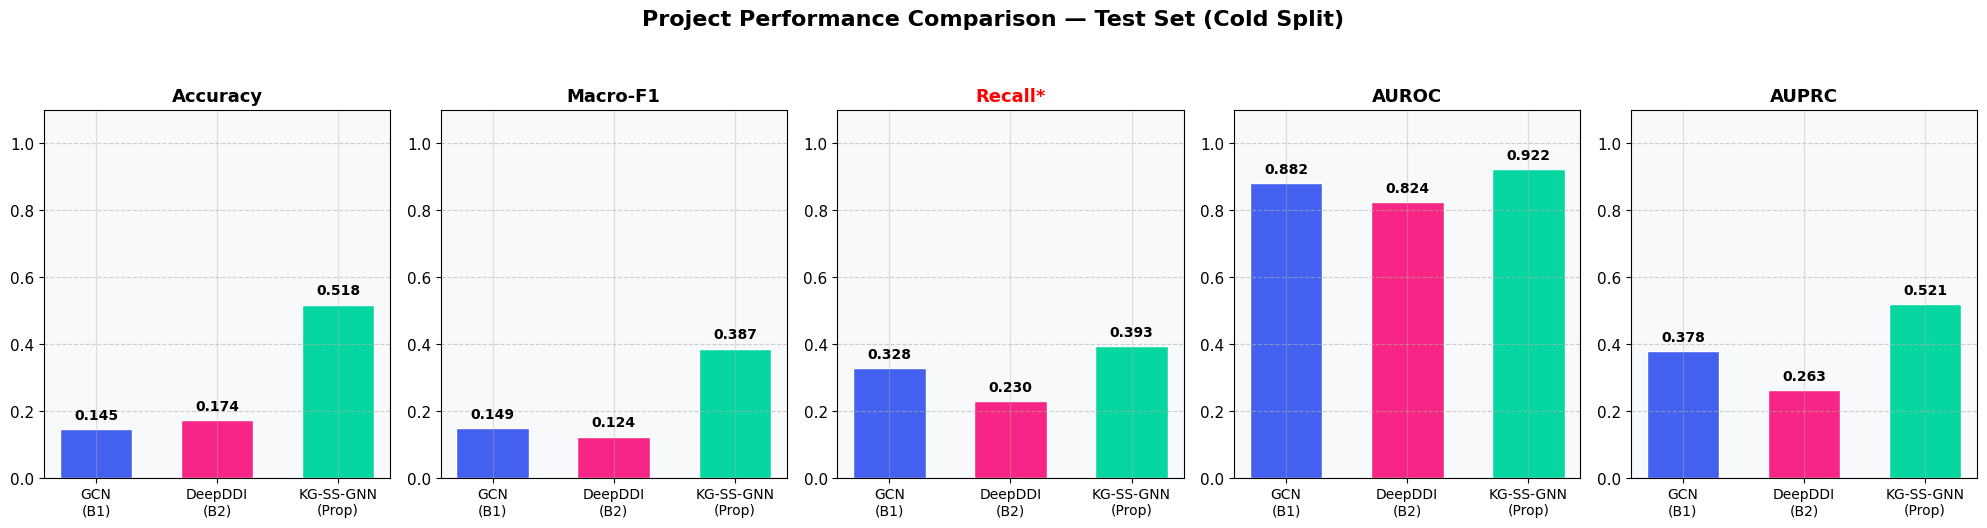

In [64]:
metrics  = ['acc', 'macro_f1', 'recall', 'auroc', 'auprc']
m_labels = ['Accuracy', 'Macro-F1', 'Recall*', 'AUROC', 'AUPRC']
model_names = list(results.keys())

# Updated Labels for 3 models
# Shortened names for the X-axis
short_labels = ['GCN\n(B1)', 'DeepDDI\n(B2)', 'KG-SS-GNN\n(Prop)'] 
# Updated Colors (added green for the proposed model)
colors = ['#4361ee', '#f72585', '#06d6a0']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Project Performance Comparison — Test Set (Cold Split)', fontsize=16, fontweight='bold', y=1.05)

for i, (ax, met, lab) in enumerate(zip(axes, metrics, m_labels)):
    vals = [results[m][met] for m in model_names]
    
    # Create the bars
    bars = ax.bar(range(len(model_names)), vals, color=colors, edgecolor='white', width=0.6)
    
    # Axis formatting
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(short_labels, fontsize=10)
    ax.set_ylim(0, 1.1) 
    ax.set_title(lab, fontweight='bold')
    
    # Add values on top of bars
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Highlight Recall as requested
    if met == 'recall':
        ax.set_title(lab, color='red', fontweight='bold')
    
    # Add a slight grid for readability
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
# Manually restoring your new, better results for the plots
proposed_history = [
    {'epoch': 1,   'loss': 0.4626, 'macro_f1': 0.2948, 'auroc': 0.9056},
    {'epoch': 5,   'loss': 0.0902, 'macro_f1': 0.3674, 'auroc': 0.9110},
    {'epoch': 10,  'loss': 0.0746, 'macro_f1': 0.3326, 'auroc': 0.9070},
    {'epoch': 20,  'loss': 0.0637, 'macro_f1': 0.3597, 'auroc': 0.9046},
    {'epoch': 40,  'loss': 0.0489, 'macro_f1': 0.3458, 'auroc': 0.9103},
    {'epoch': 50,  'loss': 0.0410, 'macro_f1': 0.4212, 'auroc': 0.9117},
    {'epoch': 75,  'loss': 0.0233, 'macro_f1': 0.3936, 'auroc': 0.9298},
    {'epoch': 100, 'loss': 0.0139, 'macro_f1': 0.4211, 'auroc': 0.9194},
]

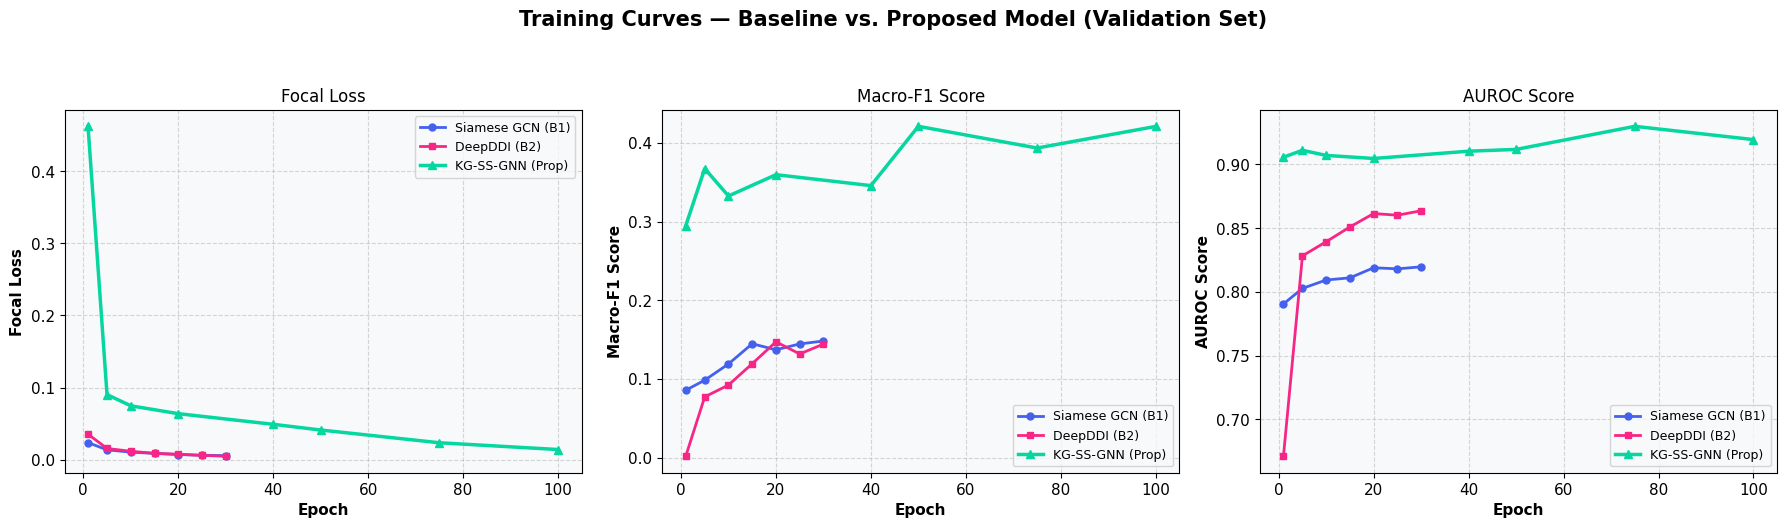

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves — Baseline vs. Proposed Model (Validation Set)', fontsize=15, fontweight='bold', y=1.05)

# Convert all histories to DataFrames
gcn_hist_df      = pd.DataFrame(gcn_history)
ddi_hist_df      = pd.DataFrame(ddi_history)
proposed_hist_df = pd.DataFrame(proposed_history) # New DataFrame

# Loop through Loss, F1, and AUROC
for ax, col, ylabel in zip(axes,
                            ['loss', 'macro_f1', 'auroc'],
                            ['Focal Loss', 'Macro-F1 Score', 'AUROC Score']):
    
    # 1. Baseline 1 (Blue)
    ax.plot(gcn_hist_df['epoch'], gcn_hist_df[col], 'o-', 
            color='#4361ee', label='Siamese GCN (B1)', lw=2, markersize=5)
    
    # 2. Baseline 2 (Pink)
    ax.plot(ddi_hist_df['epoch'], ddi_hist_df[col], 's-', 
            color='#f72585', label='DeepDDI (B2)',     lw=2, markersize=5)
    
    # 3. Proposed Model (Green)
    ax.plot(proposed_hist_df['epoch'], proposed_hist_df[col], '^-', 
            color='#06d6a0', label='KG-SS-GNN (Prop)', lw=2.5, markersize=6)

    # Formatting
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(ylabel, fontsize=12)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('final_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()